# 01 · Tutelas — Exploración Inicial
**Objetivo:** Entender la estructura del dataset antes de analizar. Aquí no se construye ningún indicador ni se saca ninguna conclusión final — solo observamos, contamos y nos preguntamos.

**Datos:** `data/tutelas - Detalle1.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATA_PATH = '../data/tutelas - Detalle1.csv'
REFERENCE_DATE = pd.Timestamp('2026-05-11')  # fecha de análisis

## 1. Carga y estructura general

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8', sep=None, engine='python')

print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print()
print('Columnas disponibles:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

Filas:    12,952
Columnas: 47

Columnas disponibles:
   1. Nombre del fichero
   2. Estado del ciclo de vida
   3. Fecha de creación
   4. Autor
   5. Clasificación TTL
   6. Compañía
   7. Fecha y hora notificación tutela
   8. Horas otorgadas
   9. Fecha Vencimiento Admision
  10. Regional T
  11. Radicado juzgado
  12. Juzgado
  13. Abogado asignado tutela
  14. Medida provisional
  15. Tiene Fallo 2da instancia
  16. Usuario área técnica EPS SALUD
  17. Usuario área técnica ARL SALUD
  18. Fecha Reasignacion Concepto Salud
  19. Fecha_Asignacion_Concepto
  20. Fecha Limite Concepto Admisión
  21. Fecha finalización concepto
  22. Area causal
  23. Area causal_Salud EPS
  24. Motivo Causal Juridico
  25. Odontologia
  26. Tutela evitable
  27. Area causal_2
  28. Area causal_3
  29. Area causal_4
  30. PBS/NO PBS
  31. Nombres Beneficiarios
  32. Accionante
  33. Fecha y hora de Contestación
  34. Fecha y hora notificación 1ra Instancia
  35. Horas para cumplimiento 1ra Instancia
  

In [3]:
# Tipos de dato y primeros valores por columna
df.dtypes.to_frame('dtype').assign(sample=df.iloc[0]).head(47)

,dtype,sample
Nombre del fichero,object,EXP-T-26-000000000 - 2025-0579 - 1011402402
Estado del ciclo de vida,object,Cumplimiento Fallo 1 Terminado
Fecha de creación,object,2026-01-02 07:33:30
Autor,object,Administrator
Clasificación TTL,object,2. Medida Provisional
Compañía,object,EPS
Fecha y hora notificación tutela,object,2025-12-31 16:45:00
Horas otorgadas,float64,48.0
Fecha Vencimiento Admision,object,2026-01-05 17:00:00
Regional T,object,ANTIOQUIA


## 2. Fechas — período cubierto y coherencia temporal

In [4]:
date_cols = [
    'Fecha de creación',
    'Fecha y hora notificación tutela',
    'Fecha Vencimiento Admision',
    'Fecha_Asignacion_Concepto',
    'Fecha Limite Concepto Admisión',
    'Fecha finalización concepto',
    'Fecha y hora de Contestación',
    'Fecha y hora notificación 1ra Instancia',
    'Fecha vencimiento fallo 1ra Instancia',
    'Fecha y hora Notificación 2da Instancia',
    'Fecha vencimiento fallo 2da Instancia',
    'Fecha y hora fallo Corte Constitucional',
    'Fecha vencimiento fallo corte',
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Rango de fechas de notificación (fecha de ingreso real de la tutela)
print('Período cubierto (notificación tutela):')
print(f'  Desde: {df["Fecha y hora notificación tutela"].min()}')
print(f'  Hasta: {df["Fecha y hora notificación tutela"].max()}')
print(f'  Nulos: {df["Fecha y hora notificación tutela"].isna().sum()}')

Período cubierto (notificación tutela):
  Desde: 2013-12-09 07:30:00
  Hasta: 2026-04-07 11:06:00
  Nulos: 88


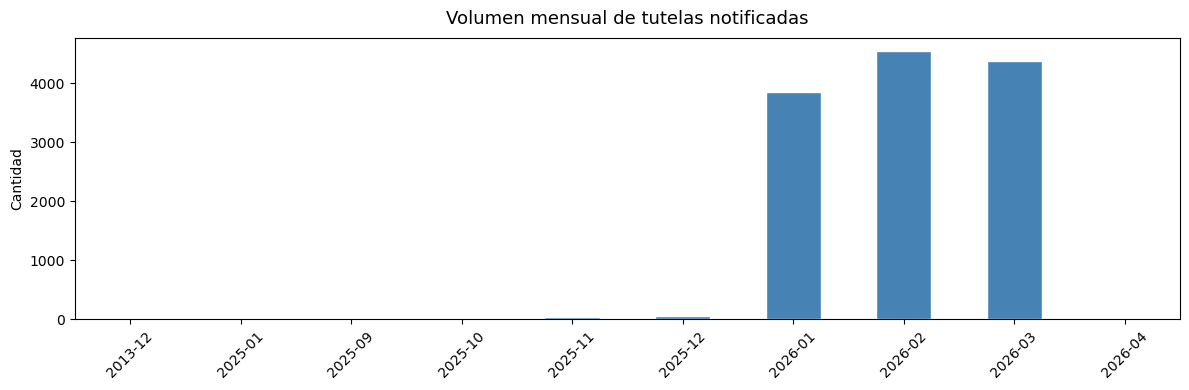

In [5]:
# Volumen mensual de tutelas
df['mes_notificacion'] = df['Fecha y hora notificación tutela'].dt.to_period('M')
vol_mensual = df['mes_notificacion'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
vol_mensual.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Volumen mensual de tutelas notificadas', fontsize=13, pad=10)
ax.set_xlabel('')
ax.set_ylabel('Cantidad')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Investigación: ¿por qué el gráfico muestra casi todo en 2026?

In [6]:
# ── 1. Conteo por año de notificación ──────────────────────────────────────
df['año_notif'] = df['Fecha y hora notificación tutela'].dt.year
print('Distribución por año de notificación (incluye NaT como NaN):')
print(df['año_notif'].value_counts(dropna=False).sort_index().to_string())
print(f'\nTotal con fecha válida : {df["año_notif"].notna().sum():,}')
print(f'Total sin fecha (NaT)  : {df["año_notif"].isna().sum():,}')


Distribución por año de notificación (incluye NaT como NaN):
año_notif
2013.0        1
2025.0      112
2026.0    12751
NaN          88

Total con fecha válida : 12,864
Total sin fecha (NaT)  : 88


In [7]:
# ── 2. Inspeccionar los registros con fechas fuera de 2026 ─────────────────
outliers = df[df['año_notif'].notna() & (df['año_notif'] != 2026)].copy()
print(f'Registros con fecha de notificación fuera de 2026: {len(outliers)}')
print()

if len(outliers) > 0:
    print('Distribución por año:')
    print(outliers['año_notif'].value_counts().sort_index().to_string())
    print()
    print('Muestra de registros con fechas antiguas (antes de 2025):')
    sample_old = outliers[outliers['año_notif'] < 2025][
        ['Fecha de creación', 'Fecha y hora notificación tutela', 'Estado del ciclo de vida', 'Regional T']
    ].head(10)
    print(sample_old.to_string())


Registros con fecha de notificación fuera de 2026: 113

Distribución por año:
año_notif
2013.0      1
2025.0    112

Muestra de registros con fechas antiguas (antes de 2025):
        Fecha de creación Fecha y hora notificación tutela Estado del ciclo de vida Regional T
11956 2026-03-24 15:06:38              2013-12-09 07:30:00          Espera de Fallo  ANTIOQUIA


In [9]:
# ── 3. Comparar fecha de notificación vs. fecha de creación del registro ────
# Hipótesis: la "Fecha de creación" refleja cuándo se cargó al sistema (2026),
# pero la "Fecha y hora notificación tutela" podría tener fechas históricas reales.
print('Fecha de CREACIÓN del registro — distribución por año:')
df['año_creacion'] = df['Fecha de creación'].dt.year
print(df['año_creacion'].value_counts(dropna=False).sort_index().to_string())
print()
print('Fecha de NOTIFICACIÓN — distribución por año:')
print(df['año_notif'].value_counts(dropna=False).sort_index().to_string())
print()

# ¿Los registros con fechas antiguas en notificación tienen creación reciente?
if len(outliers) > 0:
    print('Para los outliers (notificación fuera de 2026):')
    subset = outliers[['Fecha de creación', 'Fecha y hora notificación tutela']]
    print(f'  Fecha creación  — min: {subset["Fecha de creación"].min()}  max: {subset["Fecha de creación"].max()}')
    print(f'  Fecha notif.    — min: {subset["Fecha y hora notificación tutela"].min()}  max: {subset["Fecha y hora notificación tutela"].max()}')
    print(f'  Total outliers  : {len(outliers)}')


Fecha de CREACIÓN del registro — distribución por año:
año_creacion
2026    12952

Fecha de NOTIFICACIÓN — distribución por año:
año_notif
2013.0        1
2025.0      112
2026.0    12751
NaN          88

Para los outliers (notificación fuera de 2026):
  Fecha creación  — min: 2026-01-02 07:33:30  max: 2026-03-30 08:21:07
  Fecha notif.    — min: 2013-12-09 07:30:00  max: 2025-12-31 16:56:00
  Total outliers  : 113


In [10]:
# ── 4. Verificar si las fechas "vacías" en el gráfico son realmente NaT ─────
# El gráfico mostraba etiquetas como 2013-12, 2025-01, etc. con barra casi cero.
# Chequear si son 1 solo registro o un artefacto visual del eje.

print('Todos los meses con ≤5 tutelas (posibles outliers o errores de fecha):')
pocos = vol_mensual[vol_mensual <= 5]
print(pocos.to_string())
print()
print(f'Total meses con ≤5 registros: {len(pocos)}')
print(f'Total registros en esos meses: {pocos.sum()}')
print()

# Mostrar esos registros completos para inspeccionarlos
meses_raros = pocos.index.astype(str).tolist()
df['mes_str'] = df['mes_notificacion'].astype(str)
registros_raros = df[df['mes_str'].isin(meses_raros)][
    ['Fecha de creación', 'Fecha y hora notificación tutela', 'Estado del ciclo de vida',
     'Regional T', 'Radicado juzgado']
]
print('Registros con fechas atípicas:')
print(registros_raros.to_string())


Todos los meses con ≤5 tutelas (posibles outliers o errores de fecha):
mes_notificacion
2013-12    1
2025-01    3
2025-09    1
2026-04    1
Freq: M

Total meses con ≤5 registros: 4
Total registros en esos meses: 6

Registros con fechas atípicas:
        Fecha de creación Fecha y hora notificación tutela        Estado del ciclo de vida Regional T Radicado juzgado
332   2026-01-07 11:06:10              2026-04-07 11:06:00  Cumplimiento Fallo 1 Terminado      NORTE        2025-0336
2518  2026-01-23 07:13:36              2025-01-23 18:50:00                         Nulidad  OCCIDENTE        2025-0414
3481  2026-01-29 08:04:23              2025-01-29 07:30:00                Fallo 2 cumplido  OCCIDENTE        2026-0091
9306  2026-03-05 15:51:52              2025-09-25 09:49:00                 Fallo Favorable      NORTE        2025-0835
11956 2026-03-24 15:06:38              2013-12-09 07:30:00                 Espera de Fallo  ANTIOQUIA        2013-1181
12840 2026-03-30 08:21:07              2

## 3. Campos categóricos clave — valores únicos y distribución

In [6]:
cat_cols = {
    'Estado del ciclo de vida': 'Estado / etapa del proceso',
    'Compañía': 'Compañía (EPS / ARL)',
    'Regional T': 'Regional',
    'Area causal': 'Área causal',
    'Motivo Causal Juridico': 'Motivo causal jurídico',
    'Clasificación fallo 1ra Instancia': 'Fallo 1ra instancia',
    'Clasificación fallo 2da Instancia': 'Fallo 2da instancia',
    'Tipos respuesta': 'Tipo de respuesta',
    'Medida provisional': 'Medida provisional',
    'PBS/NO PBS': 'PBS / No PBS',
}

for col, label in cat_cols.items():
    vc = df[col].value_counts(dropna=False)
    print(f'── {label} ({col}) ── {len(vc)} valores únicos')
    print(vc.head(10).to_string())
    print()

── Estado / etapa del proceso (Estado del ciclo de vida) ── 18 valores únicos
Estado del ciclo de vida
Fallo Favorable                   5356
fallo 1 cumplido                  2446
Cumplimiento Fallo 1 Terminado    1412
Gestión fallo 1 área              1407
Fallo 2 cumplido                   643
Espera de Fallo                    298
Expediente Anulado                 283
Fallo Primera Instancia            269
Espera Fallo 2                     267
Cumplimiento fallo 2 Terminado     237

── Compañía (EPS / ARL) (Compañía) ── 8 valores únicos
Compañía
EPS                    10050
ARL                     2062
SEGUROS GENERALES        365
SEGUROS DE VIDA          311
IPS SURA                 131
AYUDAS DIAGNOSTICAS       25
NaN                        7
CONSULTORIA                1

── Regional (Regional T) ── 10 valores únicos
Regional T
ANTIOQUIA                                      6128
NORTE                                          2013
CENTRO                                         1

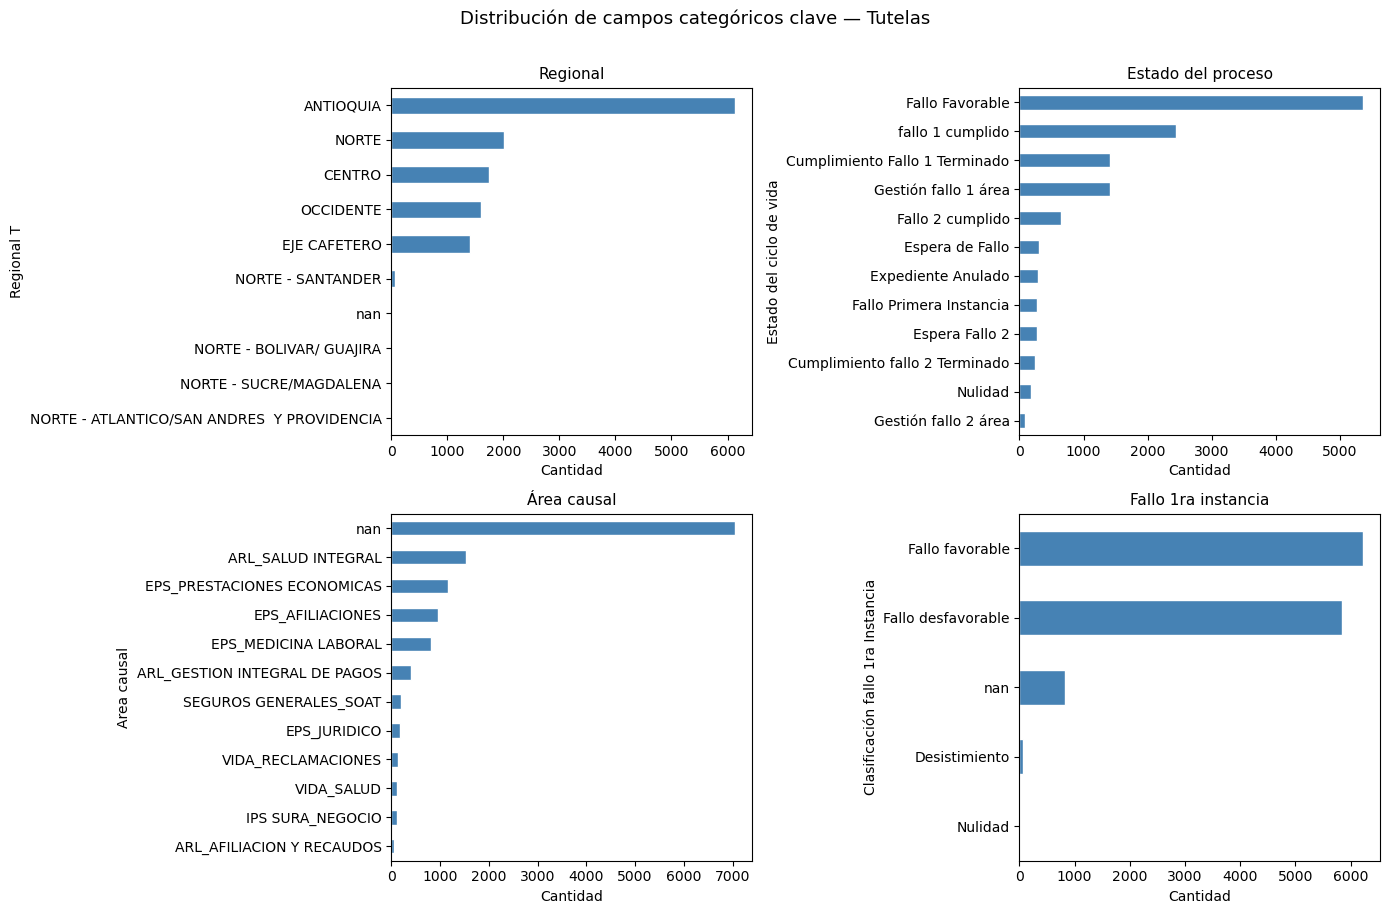

In [7]:
# Distribución visual de los 4 campos más relevantes para el negocio
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_fields = [
    ('Regional T', 'Regional'),
    ('Estado del ciclo de vida', 'Estado del proceso'),
    ('Area causal', 'Área causal'),
    ('Clasificación fallo 1ra Instancia', 'Fallo 1ra instancia'),
]

for ax, (col, title) in zip(axes.flat, plot_fields):
    vc = df[col].value_counts(dropna=False).head(12)
    vc.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Cantidad')
    ax.invert_yaxis()

plt.suptitle('Distribución de campos categóricos clave — Tutelas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Nulos por columna — mapa de completitud

In [8]:
nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'pct_nulo': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('pct_nulo', ascending=False)

print('Columnas con nulos (ordenado de mayor a menor):')
print(nulos[nulos['nulos'] > 0].to_string())

Columnas con nulos (ordenado de mayor a menor):
                                         nulos  pct_nulo
Tutela evitable                          12952     100.0
Prestación sucesiva 1ra instancia        12952     100.0
Fecha y hora fallo Corte Constitucional  12952     100.0
Fecha vencimiento fallo corte            12952     100.0
PBS/NO PBS                               12952     100.0
Area causal_4                            12951     100.0
Motivo Causal Juridico                   12952     100.0
Area causal_3                            12920      99.8
Odontologia                              12874      99.4
Area causal_2                            12180      94.0
Clasificación fallo 2da Instancia        11303      87.3
Fecha y hora Notificación 2da Instancia  11224      86.7
Horas para cumplimiento 2da Instancia    11224      86.7
Fecha vencimiento fallo 2da Instancia    11224      86.7
Usuario área técnica ARL SALUD           11056      85.4
Tiene Fallo 2da instancia               

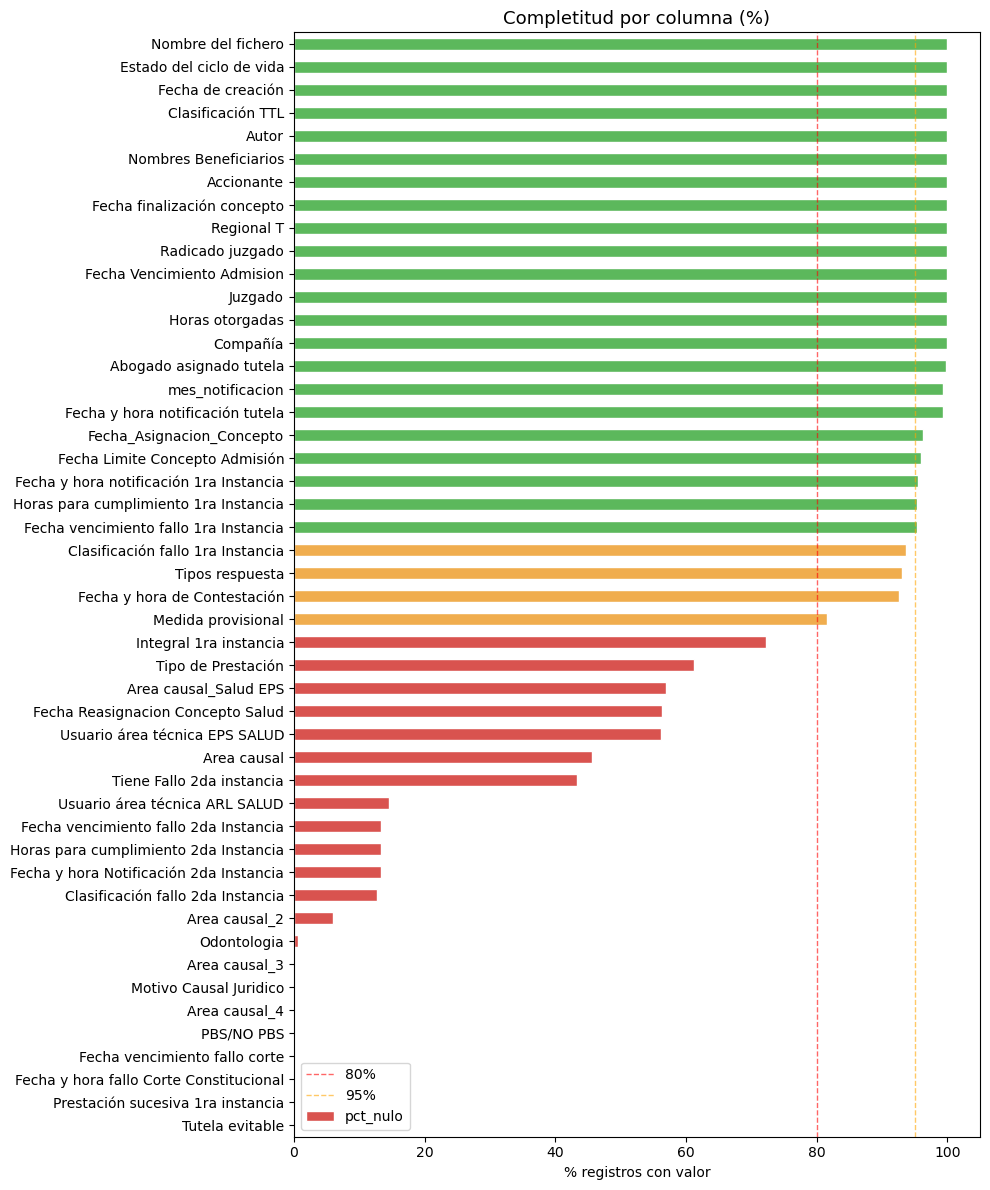

In [9]:
# Visualizar completitud
completitud = (100 - nulos['pct_nulo']).sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#d9534f' if v < 80 else '#f0ad4e' if v < 95 else '#5cb85c' for v in completitud]
completitud.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(80, color='red', linestyle='--', linewidth=1, alpha=0.6, label='80%')
ax.axvline(95, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='95%')
ax.set_title('Completitud por columna (%)', fontsize=13)
ax.set_xlabel('% registros con valor')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Abogados asignados — carga de trabajo

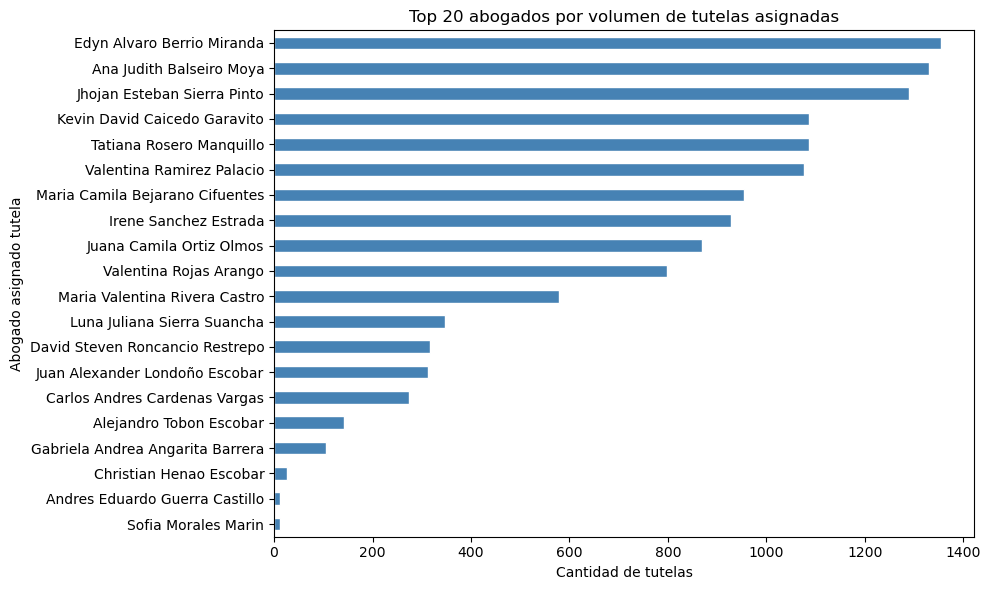

Total abogados distintos: 25


In [10]:
carga = df['Abogado asignado tutela'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
carga.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 abogados por volumen de tutelas asignadas', fontsize=12)
ax.set_xlabel('Cantidad de tutelas')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Total abogados distintos: {df["Abogado asignado tutela"].nunique()}')

## 6. Resumen de exploración

**Anotar aquí los hallazgos de exploración para llevar al documento ejecutivo:**

- Total de registros y período cubierto
- Campos con alta tasa de nulos que pueden limitar el análisis
- Valores extraños o categorías inesperadas
- Preguntas pendientes para el notebook de calidad (02)

> Continuar en `02_tutelas_quality.ipynb`